In [14]:
from pathlib import Path

import numpy as np
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit
from treeple.ensemble import HonestForestClassifier
from treeple.datasets import (make_trunk_classification,
                              make_trunk_mixture_classification)
from treeple.stats import PermutationHonestForestClassifier, build_oob_forest
from treeple.stats.utils import _mutual_information
from treeple.tree import MultiViewDecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import os
from treeple.ensemble import ObliqueRandomForestClassifier
from treeple.tree import  ObliqueDecisionTreeClassifier
from treeple.tree import  PatchObliqueDecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import MDS
# from random import shuffle

import pandas as pd
import time
import os


from treeple._lib.sklearn.tree._criterion import Gini
from treeple.tree._oblique_splitter import BestObliqueSplitterTester
from treeple.datasets import make_trunk_classification
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

In [2]:

n_estimators = 100000
MODEL_NAMES = {
    "might": {
        # "n_estimators": n_estimators,
        # "honest_fraction": 0.367,
        # "n_jobs": 40,
        # "bootstrap": True,
        # "stratify": True,
        # "max_samples": 1.6,
        # # "max_features":  'sqrt',
        # # "max_features":  0.3,
        # "honest_prior": "ignore",
        # "honest_method": 'apply',
        # "kernel_method": True,
        # # 'random_state': 80515
    },
        "rf": {
        "n_estimators": int(n_estimators/5),
        "max_features": 'sqrt',
    },
    "knn": {
        # XXX: above, we use sqrt of the total number of samples to allow
        # scaling wrt the number of samples
        # "n_neighbors": 5,
    },
    "svm": {
        "probability": True,
    },
    "lr": {
        "max_iter": 1000,
        "penalty": "l1",
        "solver": "liblinear",
    }
}
might_kwargs = MODEL_NAMES["might"]

filelist = open("/home/ybai31/might/filelist.txt", "r").read().split("\n")[:-1]

# get the sample list
sample_list_file = "/home/ybai31/might/AllSamples.MIGHT.Passed.samples.txt"
sample_list = pd.read_csv(sample_list_file, sep=" ", header=None)
sample_list.columns = ["library", "sample_id", "cohort"]
sample_list.head()
# get the sample_ids where cohort is Cohort1
cohort1 = sample_list[sample_list["cohort"] == "Cohort1"]["sample_id"]
# print(len(cohort1))
cohort2 = sample_list[sample_list["cohort"] == "Cohort2"]["sample_id"]
# print(len(cohort2))
PON = sample_list[sample_list["cohort"] == "PanelOfNormals"]["sample_id"]
# print(cohort1)
sample_list["cohort"].unique()

normal_sample = pd.read_csv('/home/ybai31/might/Normal', sep=" ", header=None) 
normal_sample.columns = ["library", "sample_id"]
print(len(normal_sample))


cancer_sample = pd.read_csv('/home/ybai31/might/Cancer', sep=" ", header=None) 
cancer_sample.columns = ["library", "sample_id"]
cancer_sample_id = cancer_sample ["sample_id"]


549


In [3]:
filelist[23]

'WiseCondorX.Wise-1.csv'

In [4]:
i = 23
file_base = os.path.splitext(filelist[i])[0]

In [5]:
file_base

'WiseCondorX.Wise-1'

In [12]:
def get_X_y(f, root="/home/hao/comight_real_data/ManuscriptFeatureMatrices/", cohort=cohort2, verbose=False):
    df = pd.read_csv(root + f)
    non_features = ['Run', 'Library', 'Cancer Status', 'Tumor type', 'Stage', 'Library volume (uL)', 'Library Volume', 'UIDs Used', 'Experiment', 'P7', 'P7 Primer', 'MAF']
    sample_ids = df["Sample"]
    sample_ids_type = df['Sample']
    print(sample_ids_type.shape[0])    
    
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            # print(sample_id.split(".")[1])
            if "Wise" in f or 'ichorCNA' in f:
                sample_ids[i] = sample_id
            else:
                sample_ids[i] = sample_id.split(".")[1]
                
                
    for i, sample_id_type in enumerate(sample_ids_type):
        if "." in sample_id_type:
            # print(sample_id.split(".")[1])
            if "Wise" in f or 'ichorCNA' in f:
                sample_ids_type[i] = sample_id_type
            else:
                sample_ids_type[i] = sample_id_type.split(".")[1]   
                
    target = 'Cancer Status'
    y = df[target]
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        X = df[(sample_ids.isin(cohort) & sample_ids.isin(sample_ids_type))]
        y = y[(sample_ids.isin(cohort) & sample_ids.isin(sample_ids_type))]
    else:
        X = df
    if "Wise" in f:
        # replace nans with zero
        # print('Wise')
        X = X.fillna(0)
    # impute the nan values with the mean of the column
    X.iloc[:,1:] = X.iloc[:,1:].fillna(X.iloc[:,1:].mean(axis=0))
    # print(X.shape)
    # check if there are nan values
    # nan_rows = X.isnull().any(axis=1)
    nan_cols = X.isnull().all(axis=0)
    # remove the columns with all nan values
    X = X.loc[:, ~nan_cols]
    # print(X.shape)
    if verbose:
        if nan_cols.sum() > 0:
            print(f)
            print(f"nan_cols: {nan_cols.sum()}")
            print(f"X shape: {X.shape}, y shape: {y.shape}")
        else:
            print(f)
            print(f"X shape: {X.shape}, y shape: {y.shape}")
    # X = X.dropna()
    # y = y.drop(nan_rows.index)
    print('num of cancer',np.sum(y))
    return X, y

In [7]:
X_1,y_1 = get_X_y('{}.csv'.format(file_base), cohort=cohort2, verbose=True)

1989


/tmp/ipykernel_29893/4183978847.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace("Cancer", 1)


WiseCondorX.Wise-1.csv
X shape: (1447, 2524), y shape: (1447,)
num of cancer 1143


In [8]:
X = X_1.drop("Sample", axis=1).values
X = np.array(X)
y = np.array(y_1)

In [9]:
y.max()

np.int64(1)

In [13]:



def plot_proj_existing_data(X, y,
                max_features=10, 
                feature_combinations=1.5,
                plot_fig=True,
                random_state=1):
    '''
    Plot the projection matrix from treeple for existing data
    '''

    criterion = Gini(1, np.array((0, 1)))

    min_samples_leaf = 1
    min_weight_leaf = 0.0
    random_state = np.random.RandomState(random_state)
    n_samples= X.shape[0]
    n_features= X.shape[1]

    #feature_combinations = 3.0
    monotonic_cst = None
    missing_value_feature_mask = None

    # X, y = make_trunk_classification(n_samples=n_samples, n_dim=n_features, n_informative=600, seed=0)
    y = y.reshape(-1,1).astype(np.float64)
    X= X.astype(np.float32)

    sample_weight = np.ones(n_samples)

    splitter = BestObliqueSplitterTester(
        criterion,
        max_features,
        min_samples_leaf,
        min_weight_leaf,
        random_state,
        monotonic_cst,
        feature_combinations,
    )
    splitter.init_test(X, y, sample_weight, missing_value_feature_mask)


    projection_matrix = splitter.sample_projection_matrix_py()
    


    if plot_fig:
        # Visualize the projection matrix
        cmap = ListedColormap(["orange", "white", "green"])

        # Create a heatmap to visualize the indices
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.imshow(projection_matrix, cmap=cmap, aspect=n_features / max_features, interpolation="none")

        ax.set(title="Sampled Projection Matrix", xlabel="Feature Index", ylabel="Projection Vector Index")
        ax.set_xticks(np.arange(n_features))
        ax.set_yticks(np.arange(max_features))
        ax.set_yticklabels(np.arange(max_features, dtype=int) + 1)
        ax.set_xticklabels(np.arange(n_features, dtype=int) + 1)

        # Create a mappable object
        sm = ScalarMappable(cmap=cmap)
        sm.set_array([])  # You can set an empty array or values here

        # Create a color bar with labels for each feature set
        colorbar = fig.colorbar(sm, ax=ax, ticks=[0, 0.5, 1], format="%d")
        colorbar.set_label("Projection Weight")
        colorbar.ax.set_yticklabels(["-1", "0", "1"])

        plt.show()
    print("===========================================================================")
    print("projection matrix shape:", projection_matrix.shape)
    print("Created projection matrix with the following parameters:")
    print(f"n_feature = ", n_features, 
          "\nn_samples = ", n_samples, 
          "\nmax_features = ", max_features, 
          "\nfeature_combinations = ", feature_combinations)
    print("max_features * feature_combinations = ", max_features * feature_combinations)
    print("Number of non-zeros: ",len(projection_matrix.nonzero()[0]))
    return projection_matrix, len(projection_matrix.nonzero()[0])



def get_stats(proj_matrix):
    n_rows = proj_matrix.shape[0]
    n_cols = proj_matrix.shape[1]
    n_nonzero = len(proj_matrix.nonzero()[0])
    n_nonzero_per_row = n_nonzero / n_rows
    return (n_rows, n_cols, n_nonzero, n_nonzero_per_row)


In [10]:
def get_matrics_stats(model, tree_idx, n_features, plot_fig=True, feature_combinations=1.5):
    sparse_matrix = model[tree_idx].root_projection_matrix_
    weight = sparse_matrix[0]
    index = sparse_matrix[1]


    pairs = [(row, col) for row, cols in enumerate(index) for col in cols]
    n_nonzeros =  len(pairs)
    n_rows = len(sparse_matrix[0])    
    n_nonzeros_per_row = n_nonzeros/n_rows

    projection_matrix = np.zeros((n_rows, n_features), dtype=np.float32)
    for row, (cols, ws) in enumerate(zip(index, weight)):
        for col, w in zip(cols, ws):
            projection_matrix[row, col] = w

    

    if plot_fig:
        # Visualize the projection matrix
        cmap = ListedColormap(["orange", "white", "green"])

        # Create a heatmap to visualize the indices
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.imshow(projection_matrix, cmap=cmap, aspect=n_features / n_rows, interpolation="none")

        ax.set(title="Sampled Projection Matrix", xlabel="Feature Index", ylabel="Projection Vector Index")
        ax.set_xticks(np.arange(n_features))
        ax.set_yticks(np.arange(n_rows))
        ax.set_yticklabels(np.arange(n_rows, dtype=int) + 1)
        ax.set_xticklabels(np.arange(n_features, dtype=int) + 1)

        # Create a mappable object
        sm = ScalarMappable(cmap=cmap)
        sm.set_array([])  # You can set an empty array or values here

        # Create a color bar with labels for each feature set
        colorbar = fig.colorbar(sm, ax=ax, ticks=[0, 0.5, 1], format="%d")
        colorbar.set_label("Projection Weight")
        colorbar.ax.set_yticklabels(["-1", "0", "1"])

        plt.show()
    print("===========================================================================")
    
    print("Projection matrix information:")
    print(f"n_feature = ", n_features, 
          "\nmax_features = ", n_rows, 
          "\nfeature_combinations = ", feature_combinations)
    print("projection matrix shape:", projection_matrix.shape)
    print("max_features * feature_combinations = ", n_rows * feature_combinations)
    print("Number of non-zeros: ",n_nonzeros)  
    print("Number of non-zeros per row: ", n_nonzeros_per_row)

    return projection_matrix, n_nonzeros, n_rows, n_nonzeros_per_row



## wise 1

In [ ]:
proj_matrix, weights = plot_proj_existing_data(X, y,
                max_features=50, 
                feature_combinations=1.5,
                plot_fig=False,
                random_state=1)

projection matrix shape: (50, 2523)
Created projection matrix with the following parameters:
n_feature =  2523 
n_samples =  1447 
max_features =  50 
feature_combinations =  1.5
max_features * feature_combinations =  75.0
Number of non-zeros:  75


In [12]:
get_stats(proj_matrix)

(50, 2523, 75, 1.5)

In [42]:
from treeple.tree._oblique_splitter import BestObliqueSplitter

model = ObliqueRandomForestClassifier(n_estimators=10, 
                                      max_features=50, 
                                      random_state=42, 
                                      feature_combinations=1.5,
                                      bootstrap=False)
model.fit(X,y)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,50
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


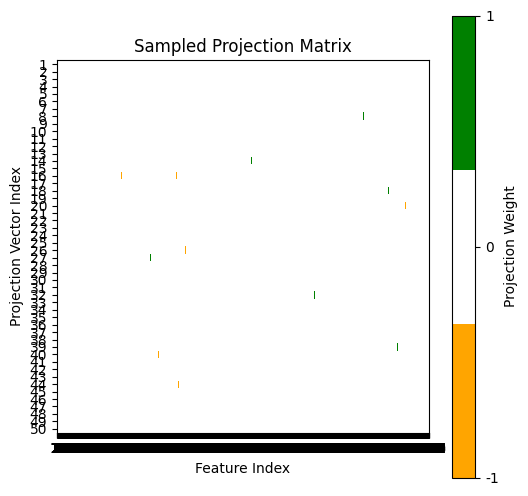

Projection matrix information:
n_feature =  2523 
max_features =  50 
feature_combinations =  1.5
projection matrix shape: (50, 2523)
max_features * feature_combinations =  75.0
Number of non-zeros:  75
Number of non-zeros per row:  1.5


In [61]:

projection_matrix, n_nonzeros, n_rows, n_nonzeros_per_row = get_matrics_stats(model, 1, X.shape[1], plot_fig=True, feature_combinations=1.5)

In [57]:
model[0].first_best_split_

(1442, -2.047534465789795)

In [47]:
projection_matrix.nonzero()

(array([ 0,  1,  2,  2,  3,  3,  3,  6,  7,  7,  7,  9, 10, 11, 11, 12, 12,
        12, 13, 13, 14, 15, 15, 15, 16, 17, 17, 17, 17, 17, 18, 19, 21, 22,
        23, 23, 23, 23, 24, 25, 25, 25, 25, 26, 26, 29, 29, 29, 29, 31, 31,
        32, 32, 32, 32, 34, 34, 35, 36, 36, 37, 38, 39, 39, 42, 42, 42, 43,
        44, 45, 45, 46, 46, 47, 47]),
 array([1920,  999, 2231, 2374, 1253, 1357, 1595,  446,  232,  295, 2073,
        1276, 1229,  433,  904,  772,  866, 2318,  778, 1315,  866,  201,
         436,  808,  480,  195, 1744, 1772, 2242, 2474,  763, 2357, 1758,
        1558,  178, 1765, 2138, 2429,  974,  869,  960, 1895, 2292,  632,
        2098,  218,  938, 1607, 1708, 1741, 1810,  150, 1155, 1693, 2098,
         472, 1530, 2248,  417,  607, 1030, 2303,  563,  686,  337, 1351,
        1878,  821,  305,  193,  374,   44, 1757,  311,  431]))

In [ ]:
f

(913, -4.276557445526123)

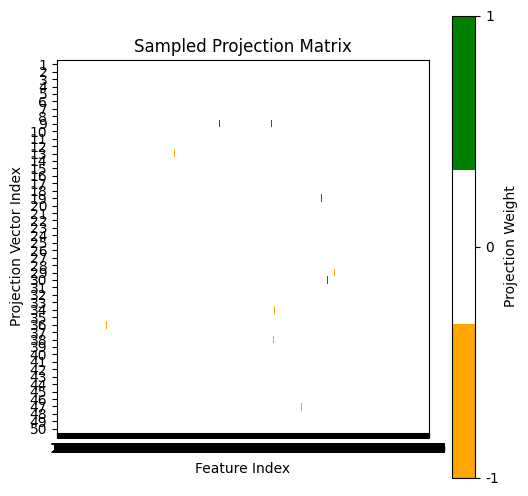

projection matrix shape: (50, 2523)
Created projection matrix with the following parameters:
n_feature =  2523 
n_samples =  1447 
max_features =  50 
feature_combinations =  1.5
max_features * feature_combinations =  75.0
Number of non-zeros:  75


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 2523), dtype=float32),
 75)

In [38]:
plot_proj_existing_data(X, y,
                max_features=50, 
                feature_combinations=1.5,
                plot_fig=True,
                random_state=2)

In [ ]:
def get_X_y(f, root="/home/hao/comight_real_data/ManuscriptFeatureMatrices/", cohort=cohort2, verbose=False):
    df = pd.read_csv(root + f)
    non_features = ['Run', 'Library', 'Cancer Status', 'Tumor type', 'Stage', 'Library volume (uL)', 'Library Volume', 'UIDs Used', 'Experiment', 'P7', 'P7 Primer', 'MAF']
    sample_ids = df["Sample"]
    sample_ids_type = df['Sample']
    print(sample_ids_type.shape[0])    
    
    for i, sample_id in enumerate(sample_ids):
        if "." in sample_id:
            # print(sample_id.split(".")[1])
            if "Wise" in f or 'ichorCNA' in f:
                sample_ids[i] = sample_id
            else:
                sample_ids[i] = sample_id.split(".")[1]
                
                
    for i, sample_id_type in enumerate(sample_ids_type):
        if "." in sample_id_type:
            # print(sample_id.split(".")[1])
            if "Wise" in f or 'ichorCNA' in f:
                sample_ids_type[i] = sample_id_type
            else:
                sample_ids_type[i] = sample_id_type.split(".")[1]   
                
    target = 'Cancer Status'
    y = df[target]
    # convert the labels to 0 and 1
    y = y.replace("Healthy", 0)
    y = y.replace("Cancer", 1)
    # remove the non-feature columns if they exist
    for col in non_features:
        if col in df.columns:
            df = df.drop(col, axis=1)
    nan_cols = df.isnull().all(axis=0).to_numpy()
    # drop the columns with all nan values
    df = df.loc[:, ~nan_cols]
    # if cohort is not None, filter the samples
    if cohort is not None:
        X = df[(sample_ids.isin(cohort) & sample_ids.isin(sample_ids_type))]
        y = y[(sample_ids.isin(cohort) & sample_ids.isin(sample_ids_type))]
    else:
        X = df
    if "Wise" in f:
        # replace nans with zero
        # print('Wise')
        X = X.fillna(0)
    # impute the nan values with the mean of the column
    X.iloc[:,1:] = X.iloc[:,1:].fillna(X.iloc[:,1:].mean(axis=0))
    # print(X.shape)
    # check if there are nan values
    # nan_rows = X.isnull().any(axis=1)
    nan_cols = X.isnull().all(axis=0)
    # remove the columns with all nan values
    X = X.loc[:, ~nan_cols]
    # print(X.shape)
    if verbose:
        if nan_cols.sum() > 0:
            print(f)
            print(f"nan_cols: {nan_cols.sum()}")
            print(f"X shape: {X.shape}, y shape: {y.shape}")
        else:
            print(f)
            print(f"X shape: {X.shape}, y shape: {y.shape}")
    # X = X.dropna()
    # y = y.drop(nan_rows.index)
    print('num of cancer',np.sum(y))
    return X, y

In [13]:
proj_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 2523), dtype=float32)

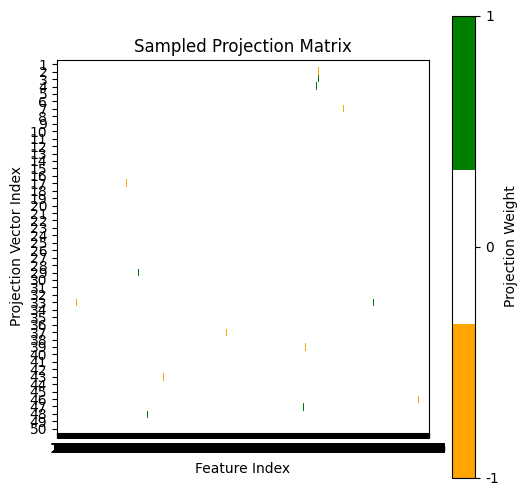

projection matrix shape: (50, 2523)
Created projection matrix with the following parameters:
n_feature =  2523 
n_samples =  1447 
max_features =  50 
feature_combinations =  1.5
max_features * feature_combinations =  75.0
Number of non-zeros:  75


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 2523), dtype=float32),
 75)

In [39]:
plot_proj_existing_data(X, y,
                max_features=50, 
                feature_combinations=1.5,
                plot_fig=True,
                random_state=3)

# processed wise1

In [7]:
df = pd.read_csv("processed_wise1_data.csv")

y = df['Cancer Status'].values
X = df.drop('Cancer Status', axis=1).values
X

array([[ 2.25946818e-01,  1.41604858e+00, -2.17912445e+00, ...,
         1.72967219e-01,  5.86074531e-01,  5.59110412e-01],
       [-2.66700743e+00, -1.78680085e+00, -2.03366604e+00, ...,
         4.25521521e-03,  4.69210502e-01,  3.29857653e-01],
       [-1.71025898e+00,  5.48869896e-01,  2.25922712e+00, ...,
         1.83231965e+00,  1.47052755e+00, -9.91248918e-01],
       ...,
       [-1.15837682e+00, -1.51177286e-01,  1.84953181e+00, ...,
         2.24321168e+00,  2.22671230e+00, -5.89124905e-01],
       [ 3.46246752e-01,  1.27235193e+00, -8.74087996e-01, ...,
        -8.92519319e-01,  5.26300874e-01,  6.19986688e-01],
       [-2.56837020e+00,  7.39228552e-01,  1.43349597e-03, ...,
         8.77240256e-01,  4.14352317e-01, -1.06304211e+00]],
      shape=(352, 2523))

In [8]:
X.shape

(352, 2523)

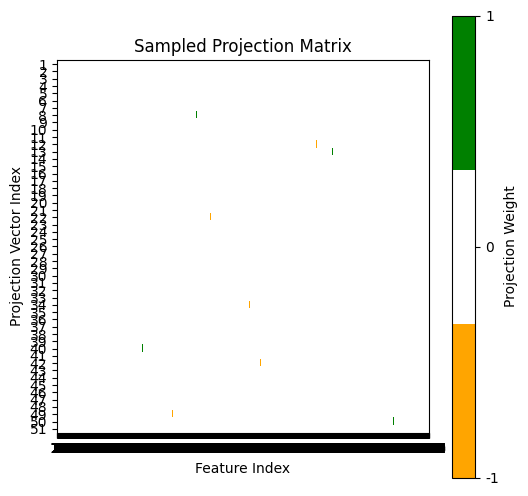

Projection matrix information:
n_feature =  2523 
max_features =  51 
feature_combinations =  1.5
projection matrix shape: (51, 2523)
max_features * feature_combinations =  76.5
Number of non-zeros:  76
Number of non-zeros per row:  1.4901960784313726


In [51]:
from treeple.tree._oblique_splitter import BestObliqueSplitter

model = ObliqueRandomForestClassifier(n_estimators=10, 
                                      max_features=51, 
                                      random_state=42, 
                                      feature_combinations=1.5,
                                      bootstrap=False)
model.fit(X,y)

projection_matrix, n_nonzeros, n_rows, n_nonzeros_per_row = get_matrics_stats(model, 0, X.shape[1], plot_fig=True, feature_combinations=1.5)

## print tree info

In [84]:
def traverse_and_print_with_matrix(clf, X32, proj_matrix, node_id=0, depth=0):
    tree = clf.tree_

    n_node_samples = tree.n_node_samples[node_id]
    threshold = tree.threshold[node_id]
    feat_id = tree.feature[node_id]
    left_id = tree.children_left[node_id]
    right_id = tree.children_right[node_id]

    # All samples at this node
    node_indicator = tree.decision_path(X32)
    samples_at_node = np.where(node_indicator[:, node_id].toarray().ravel())[0]

    print("=" * 60)
    print(f"depth       : {depth}")
    print(f"node id     : {node_id}")
    print(f"samples     : {n_node_samples}")
    print(f"threshold   : {threshold}")

    if feat_id == -2:
        print("attributes  : LEAF")
    else:
        vec = proj_matrix[feat_id]
        nz_idx = np.nonzero(vec)[0]
        nz_w   = vec[nz_idx]
        proj = ", ".join(f"x[{c}]*{w:+.2f}" for c, w in zip(nz_idx, nz_w))
        print(f"attributes  : proj_vec[{feat_id}] = {proj}")

        # Split samples manually
        vals = X32[samples_at_node] @ vec
        left_samples  = samples_at_node[vals <= threshold]
        right_samples = samples_at_node[vals >  threshold]

        print(f"negative child gets ({len(left_samples)}) examples: {left_samples.tolist()[:20]} ...")
        print(f"positive child gets ({len(right_samples)}) examples: {right_samples.tolist()[:20]} ...")

        # Recurse into children
        traverse_and_print_with_matrix(clf, X32, proj_matrix, left_id,  depth+1)
        traverse_and_print_with_matrix(clf, X32, proj_matrix, right_id, depth+1)
    print("=" * 60)

import numpy as np
import pandas as pd

def traverse_and_collect_with_matrix(clf, X32, proj_matrix, node_id=0, depth=0, results=None):
    """
    Traverse an oblique decision tree and collect node information.

    Parameters
    ----------
    clf : fitted ObliqueDecisionTreeClassifier
    X32 : np.ndarray of shape (n_samples, n_features), dtype=float32
        Training data (same dtype as used for fitting).
    proj_matrix : np.ndarray of shape (n_proj_vecs, n_features)
        Projection matrix sampled during training.
    node_id : int
        Current node index (default: root = 0).
    depth : int
        Current depth in the tree.
    results : list
        Collector for node dictionaries.

    Returns
    -------
    results : list of dict
    """
    if results is None:
        results = []

    tree = clf.tree_

    n_node_samples = tree.n_node_samples[node_id]
    threshold = tree.threshold[node_id]
    feat_id = tree.feature[node_id]
    left_id = tree.children_left[node_id]
    right_id = tree.children_right[node_id]

    node_indicator = tree.decision_path(X32)
    samples_at_node = np.where(node_indicator[:, node_id].toarray().ravel())[0]

    # default values
    proj_str, nz_idx, nz_w = None, [], []

    if feat_id != -2:
        vec = proj_matrix[feat_id]
        nz_idx = np.nonzero(vec)[0].tolist()
        nz_w   = vec[nz_idx].tolist()
        proj_str = " + ".join(f"{w:+.2f}*x[{c}]" for c, w in zip(nz_idx, nz_w))

        vals = X32[samples_at_node] @ vec
        left_samples  = samples_at_node[vals <= threshold]
        right_samples = samples_at_node[vals >  threshold]
    else:
        left_samples, right_samples = [], []

    # save info
    results.append({
        "node_id": node_id,
        "depth": depth,
        "n_samples": int(n_node_samples),
        "threshold": float(threshold),
        "feature_id": int(feat_id),
        "projection_str": proj_str,
        "proj_indices": nz_idx,
        "proj_weights": nz_w,
        "samples": samples_at_node.tolist(),
        "left_id": int(left_id),
        "right_id": int(right_id),
        "left_samples": left_samples.tolist() if len(left_samples) else [],
        "right_samples": right_samples.tolist() if len(right_samples) else [],
    })

    # recurse if not leaf
    if feat_id != -2:
        traverse_and_collect_with_matrix(clf, X32, proj_matrix, left_id,  depth+1, results)
        traverse_and_collect_with_matrix(clf, X32, proj_matrix, right_id, depth+1, results)

    return results

def pretty_print_nodes(df_nodes, depth=None, node_ids=None, max_examples=20):
    """
    Print nodes from df_nodes in a readable format.

    Parameters
    ----------
    df_nodes : pd.DataFrame
        Output from traverse_and_collect_with_matrix.
    depth : int or None
        If set, only print nodes at this depth.
    node_ids : list[int] or None
        If set, only print these node ids.
    max_examples : int
        Limit number of sample indices printed per child.
    """
    # filter
    nodes = df_nodes
    if depth is not None:
        nodes = nodes[nodes["depth"] == depth]
    if node_ids is not None:
        nodes = nodes[nodes["node_id"].isin(node_ids)]

    for _, row in nodes.iterrows():
        print("=" * 60)
        print(f"depth       : {row.depth}")
        print(f"node id     : {row.node_id}")
        print(f"attributes  : {row.projection_str if row.feature_id != -2 else 'LEAF'}")
        print(f"threshold   : {row.threshold}")
        print(f"samples     : {row.n_samples}")
        print(f"examples    : {row.samples[:max_examples]}")
        print(f"negative child gets ({len(row.left_samples)}) examples: {row.left_samples[:max_examples]}")
        print(f"positive child gets ({len(row.right_samples)}) examples: {row.right_samples[:max_examples]}")


In [69]:

projection_matrix, n_nonzeros, n_rows, n_nonzeros_per_row = get_matrics_stats(model, 0, X.shape[1], plot_fig=False, feature_combinations=1.5)


Projection matrix information:
n_feature =  2523 
max_features =  51 
feature_combinations =  1.5
projection matrix shape: (51, 2523)
max_features * feature_combinations =  76.5
Number of non-zeros:  76
Number of non-zeros per row:  1.4901960784313726


In [67]:
projection_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(51, 2523), dtype=float32)

In [73]:

X32 = X.astype(np.float32, copy=False)
traverse_and_print_with_matrix(model[0], X32, projection_matrix)

depth       : 0
node id     : 0
samples     : 352
threshold   : 0.16654297709465027
attributes  : proj_vec[32] = x[702]*+1.00, x[1165]*-1.00
negative child gets (213) examples: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...
positive child gets (139) examples: [5, 22, 23, 24, 25, 29, 30, 37, 38, 39, 40, 41, 45, 46, 48, 52, 56, 57, 58, 59] ...
depth       : 1
node id     : 1
samples     : 213
threshold   : 1.7362701296806335
attributes  : proj_vec[25] = x[1949]*-1.00
negative child gets (185) examples: [0, 1, 2, 3, 4, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 26, 28, 35] ...
positive child gets (28) examples: [6, 7, 9, 15, 27, 31, 32, 33, 34, 89, 94, 95, 104, 121, 178, 204, 207, 213, 226, 250] ...
depth       : 2
node id     : 2
samples     : 160
threshold   : -1.8463636636734009
attributes  : proj_vec[16] = 
negative child gets (0) examples: [] ...
positive child gets (160) examples: [2, 4, 6, 7, 8, 9, 11, 12, 14, 15, 17, 21, 26, 27, 31, 33, 36, 42, 43,

In [80]:
results = traverse_and_collect_with_matrix(model[0], X32, projection_matrix)


# turn into a DataFrame for easy querying
df_nodes = pd.DataFrame(results)

In [87]:
pretty_print_nodes(df_nodes, depth=0)

depth       : 0
node id     : 0
attributes  : +1.00*x[702] + -1.00*x[1165]
threshold   : 0.16654297709465027
samples     : 352
examples    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
negative child gets (213) examples: [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
positive child gets (139) examples: [5, 22, 23, 24, 25, 29, 30, 37, 38, 39, 40, 41, 45, 46, 48, 52, 56, 57, 58, 59]


In [89]:
pretty_print_nodes(df_nodes, depth=2)

depth       : 2
node id     : 2
attributes  : 
threshold   : -1.8463636636734009
samples     : 160
examples    : [2, 4, 6, 7, 8, 9, 11, 12, 14, 15, 17, 21, 26, 27, 31, 33, 36, 42, 43, 44]
negative child gets (0) examples: []
positive child gets (160) examples: [2, 4, 6, 7, 8, 9, 11, 12, 14, 15, 17, 21, 26, 27, 31, 33, 36, 42, 43, 44]
depth       : 2
node id     : 45
attributes  : +1.00*x[129] + +1.00*x[494] + -1.00*x[505] + +1.00*x[1445]
threshold   : -0.048755863681435585
samples     : 53
examples    : [0, 1, 3, 10, 13, 16, 18, 19, 20, 28, 32, 34, 35, 79, 94, 95, 100, 106, 124, 127]
negative child gets (33) examples: [0, 1, 3, 13, 18, 19, 28, 34, 35, 95, 100, 106, 124, 127, 148, 157, 177, 178, 190, 197]
positive child gets (20) examples: [10, 16, 20, 32, 79, 94, 151, 159, 161, 170, 204, 206, 238, 240, 310, 311, 312, 315, 324, 331]
depth       : 2
node id     : 59
attributes  : 
threshold   : 1.989271104335785
samples     : 92
examples    : [22, 23, 24, 29, 30, 37, 38, 39, 41, 45, 48, 

In [86]:
pretty_print_nodes(df_nodes, depth=1)

depth       : 1
node id     : 1
attributes  : -1.00*x[1949]
threshold   : 1.7362701296806335
samples     : 213
examples    : [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
negative child gets (185) examples: [0, 1, 2, 3, 4, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 26, 28, 35]
positive child gets (28) examples: [6, 7, 9, 15, 27, 31, 32, 33, 34, 89, 94, 95, 104, 121, 178, 204, 207, 213, 226, 250]
depth       : 1
node id     : 58
attributes  : -1.00*x[1064] + -1.00*x[1376]
threshold   : 1.9624137878417969
samples     : 139
examples    : [5, 22, 23, 24, 25, 29, 30, 37, 38, 39, 40, 41, 45, 46, 48, 52, 56, 57, 58, 59]
negative child gets (123) examples: [5, 22, 24, 25, 29, 37, 38, 41, 45, 46, 48, 52, 57, 58, 59, 60, 62, 63, 66, 69]
positive child gets (16) examples: [23, 30, 39, 40, 56, 167, 168, 184, 192, 223, 239, 274, 289, 294, 341, 343]


In [ ]:
df

In [77]:
df_nodes[df_nodes["depth"] == 2]

TypeError: list indices must be integers or slices, not str